In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Definició model

In [2]:
moving_source_model = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,
    ),

    medium = Dict(
        :mm => Float64
    ),

    agentODE = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x += (xmax - xmin)
        elseif x > xmax
            # idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x -= (xmax - xmin)
        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y += (ymax - ymin)
        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y -= (ymax - ymin)
        end

        mmb=mm[idx,idy]

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx  #Change position acording to constant speed afected by forces
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            mm[idx,idy] += S

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed* cos(theta)
                    vy = speed* sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed* cos(theta)
                    vy = speed* sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end

            
            xmin, xmax = simBox[1,1], simBox[1,2]
            ymin, ymax = simBox[2,1], simBox[2,2]

            if x < xmin
                x += (xmax - xmin)
            elseif x > xmax
                x -= (xmax - xmin)
            end

            # Y direction
            if y < ymin
                y += (ymax - ymin)
            elseif y > ymax
                y -= (ymax - ymin)
            end


    end,


    mediumODE = quote
        if @mediumInside()
            dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm 
        elseif @mediumBorder(1,-1)
            mm = mm[NMedium[1] - 1, i2_]
        elseif @mediumBorder(1,1)
            mm = mm[1, i2_]
        elseif @mediumBorder(2,1)
            mm = mm[i1_, 1]
        elseif @mediumBorder(2,-1)
            mm = mm[i1_, NMedium[2] - 1]
        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)

    # neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    dt__mm = DMedium * (@∂2

# Carrega community

In [3]:
com = Community(
    moving_source_model,
    N=400,
    dt=0.01,
    # simBox = [-5.0 5.0; -5.0 5.0],
    simBox = [-100.0 100.0; -100.0 100.0],
    # simBox = [-50.0 50.0; -50.0 50.0],
    # NMedium = [10, 10]
    NMedium = [200, 200]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v =  0.33   #Velocitat neutrophil (20 microm/min) 
# com.v = 20.0    #(microm/s)
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1

# com.Ds = 0.1
# com.Ds = 0.15
# com.Ds = 0.25
# com.Ds = 0.5
# com.Ds = 1
# com.Ds = 1.5
# com.Ds = 2
# com.Ds = 5
com.Ds = 10


# com.DMedium = 100
com.DMedium = 10
# com.DMedium = 1
# com.DMedium = 0.1
# com.DMedium = 0.01
# com.DMedium = 0.001
# com.DMedium = 0.0001

# com.DSource = 0.063
com.delta = 0.01
# com.delta = 0.1
# com.delta = 1.0
# com.delta = 10

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

# com.τm = 0.1
# com.τm = 0.5
com.τm = 1.0
# com.τm = 2.0
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

# com.x = -90
# com.y =  -90
com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

src = 1

# com.isSource .= false
# com.isSource[src] = true

com.active .= true 
# com.active[src] = false   

# com.S .= 0.0
# com.xs .= 0.0
# com.ys .= 0.0
# com.xs[src] = com.x[src]
# com.ys[src] = com.y[src]

# com.S[src] = 0.0025
# com.S[src] = 0.016
# com.S[src] = 0.26
com.S = 0.0025
# com.S[src] = 5

# com.S[src] = 0.1
# com.S[src] = 1
# com.S[src] = 10
# com.S[src] = 100
# com.S[src] = 1000



0.0025

In [110]:
outfile = "col_test.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=400)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")
    meta["N"] = com.N
    meta["NMedium"] = com.NMedium
    meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)
        # g["l"] = copy(com.l)
        # g["d"] = copy(com.d)
        # g["active"] = copy(com.active)
        # g["isSource"] = copy(com.isSource)

        # Medium grid (saved once per step)
        g["mm_grid"] = copy(com.mm)
    end
end


In [3]:
        com = Community(
            moving_source_model,
            N=21,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [200, 200]
        )

Community with 21 agents.


# Evoluciona i guarda

In [ ]:
n_tries = 5
ns = [5]
steps = 10000

for n in ns
    # for trial in 4:n_tries
        println("Running n=$n, trial=$trial")

        # Community
        com = Community(
            moving_source_model,
            N=21,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [200, 200]
        )

        m = 1/100
        g = 1/10000
        d = 1

        #Valors referencia
        Dc = 10
        delta = 0.01
        Ds = 10

        # Changing lambda
        com.Ds = Ds / n^2
        com.DMedium = Dc / n
        com.delta = delta * n

        # # #Changing omega
        # com.Ds = Ds
        # com.DMedium = Dc * n
        # com.delta = delta * n

        # # Changing gamma
        # com.Ds = Ds * n
        # com.DMedium = Dc
        # com.delta = delta


        com.Dr_run = 0.062
        com.v = 10.0
        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 8
        com.τm = 1.0
        com.α   = 6.0
        com.K = 2.0 
        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1
        
        com.methyl .= 0.0
        com.Yp .= com.K

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        com.x = 0.0
        com.y = 0.0
        com.theta = rand(Uniform(0,2π),com.N)
        src = 1
        com.isSource .= false
        com.isSource[src] = true
        com.active .= true 
        com.active[src] = false   
        com.S .= 0.0
        com.S[src] = 2.6

        loadToPlatform!(com, preallocateAgents=21)
        
        outfile = @sprintf("rm_lambda_%s_%d.jld2", n, trial)


        jldopen(outfile, "w") do file

            meta = JLD2.Group(file, "meta")
            meta["N"] = com.N
            meta["NMedium"] = com.NMedium
            meta["steps"] = steps

            for step in 1:steps
                step!(com)

                # if step %10000 == 0

                    stepname = @sprintf("step_%06d", step)
                    g = JLD2.Group(file, stepname)

                    # Agent-level arrays (length = N)
                    g["x"] = copy(com.x)
                    g["y"] = copy(com.y)
                    g["theta"] = copy(com.theta)
                    # g["l"] = copy(com.l)
                    # g["d"] = copy(com.d)
                    # g["isSource"] = copy(com.isSource)

                    # g["DMedium"] = copy(com.DMedium)
                    # g["delta"] = copy(com.delta)
                    # g["Ds"] = copy(com.Ds)

                    g["mm_grid"] = copy(com.mm)
                # end
            end
        # end
    end
end


Running n=5, trial=4


OutOfMemoryError: OutOfMemoryError()

# Plots

In [5]:
steps = 10000

10000

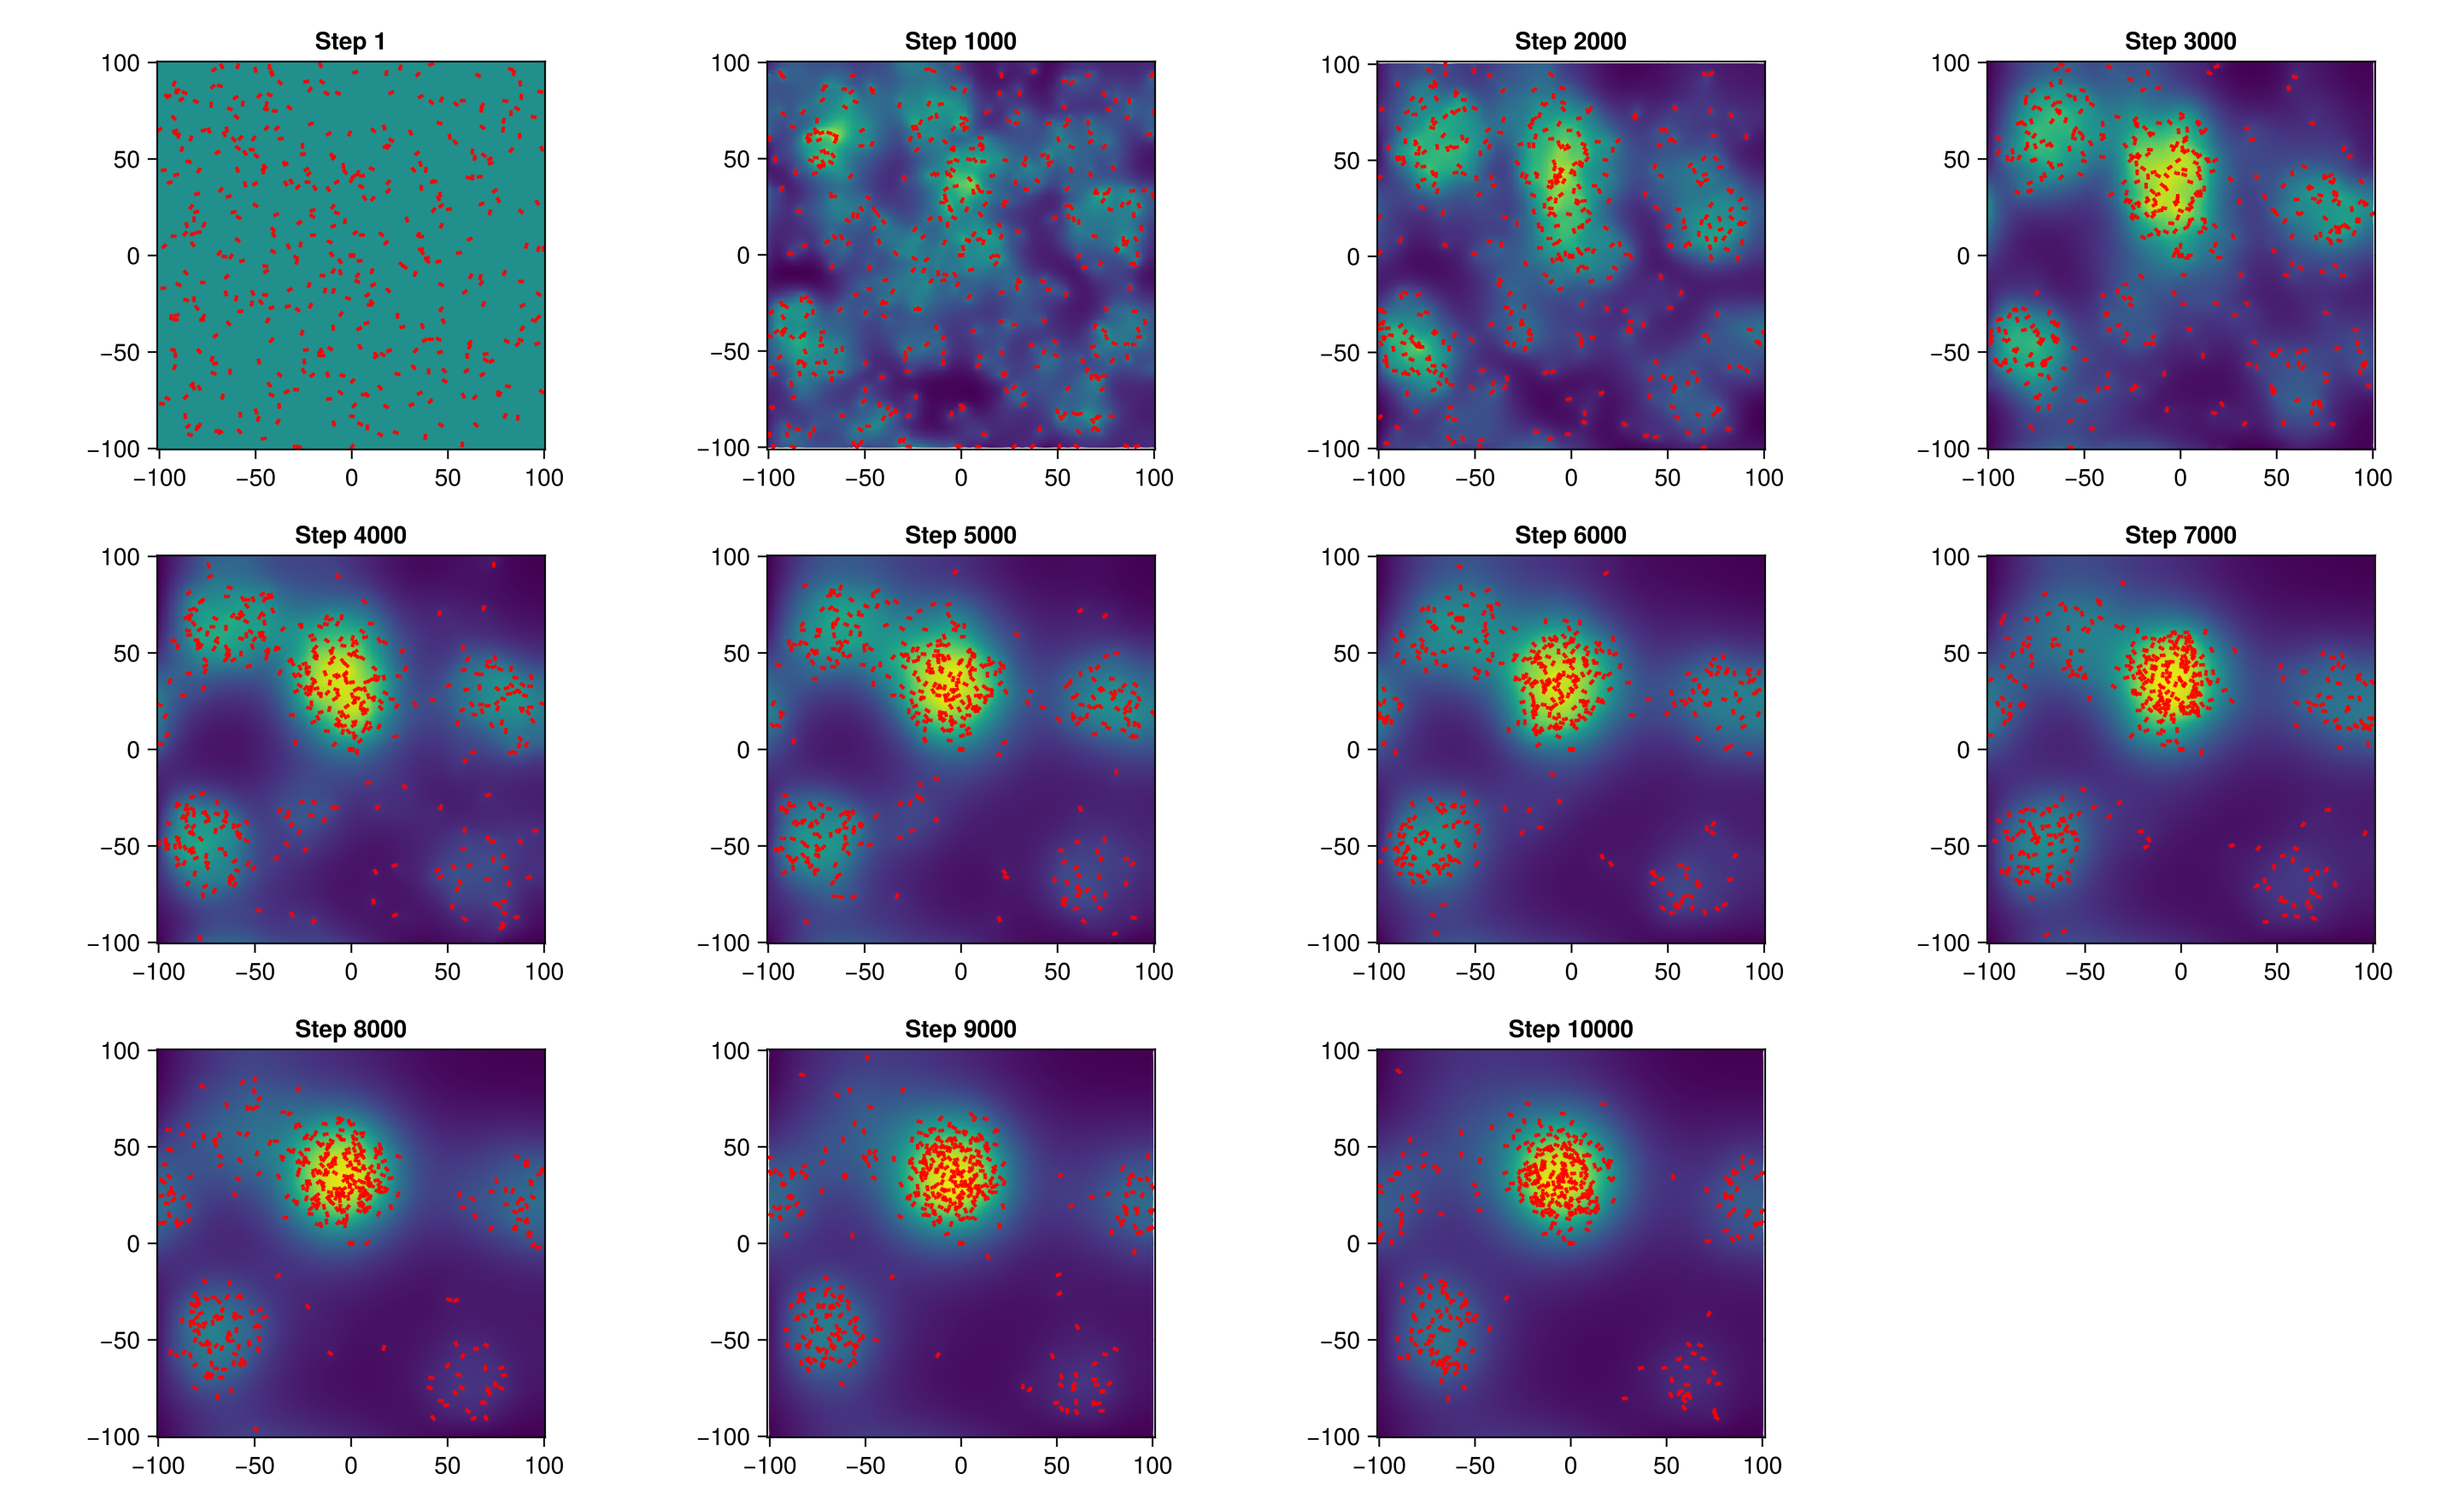

GLMakie.Screen(...)

In [11]:
fig4 = Figure(size=(900*4,600*4))
steps = 10000
model_steps = 1:steps
# steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]
steps_to_plot = [1, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

jldopen("col_test.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 1)
        y = Vector{Float64}(undef, 1)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1

        ax = Axis(fig4[row, col], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (200,200))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
                
        # scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

        # Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

In [12]:
save("Plots/Collective_model/col_test_1.png", fig4)

In [9]:
filename = "col_test.jld2"
steps = 10000
# Get all step keys
# steps = [k for k in keys(jldopen(filename, "r")) if startswith(k, "step_")]
# nsteps = length(steps)
steped = 1:steps
nsteps = length(steped)

# Define grid for heatmap (assuming 200x200)
# x_range = range(com.simBox[1,1], com.simBox[1,2], length=200)
# y_range = range(com.simBox[2,1], com.simBox[2,2], length=200)
x_range = range(-100, 100, length=200)
y_range = range(-100, 100, length=200)

# Initialize figure
fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1], aspect=1, title = "Step 1")

# Initialize scatter and lines (will be updated)
scatter_plot = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")
lines1_plot = linesegments!(ax, [0.0, 0.0], [0.0, 0.0], color=:red, linewidth=2)
lines2_plot = linesegments!(ax, [0.0, 0.0], [0.0, 0.0], color=:red, linewidth=2)

record(fig, "colective.mp4", 1:100:nsteps; framerate=10) do i
    step_key = @sprintf("step_%06d", i)
    println(i)
    jldopen(filename, "r") do file
        if !haskey(file, step_key)
            println("Warning: Key $step_key not found in file.")
            return
        end
        g = file[step_key]

        empty!(ax)

        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (200,200))

        hm = heatmap!(ax, x_range, y_range, mm, colormap=:viridis)

        # Update scatter (source)
        x = g["x"]
        y = g["y"]
        scatter_plot.positions[] = Point2f.(x[1:1], y[1:1])  # Only first point is source

        # Update rods
        theta = g["theta"]
        l = 3

        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

        # lines1_plot.segments[] = segs1
        # lines2_plot.segments[] = segs2
    end
end


1
101
201
301
401
501
601
701
801
901
1001
1101
1201
1301
1401
1501
1601
1701
1801
1901
2001
2101
2201
2301
2401
2501
2601
2701
2801
2901
3001
3101
3201
3301
3401
3501
3601
3701
3801
3901
4001
4101
4201
4301
4401
4501
4601
4701
4801
4901
5001
5101
5201
5301
5401
5501
5601
5701
5801
5901
6001
6101
6201
6301
6401
6501
6601
6701
6801
6901
7001
7101
7201
7301
7401
7501
7601
7701
7801
7901
8001
8101
8201
8301
8401
8501
8601
8701
8801
8901
9001
9101
9201
9301
9401
9501
9601
9701
9801
9901


"colective.mp4"

In [57]:
using Makie
using JLD2
using Printf

filename = "col_test.jld2"
steps = 10000

fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1], aspect=1, title = "Step 1")

x_range = range(-100, 100, length=200)
y_range = range(-100, 100, length=200)

# 1. Initialize plots ONCE
scatter_plot = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")

# Initialize linesegments with empty Point2f vectors
# We create 4 empty vectors of Point2f to match the expected type
lines1_plot = linesegments!(ax, Point2f[], Point2f[], Point2f[], Point2f[]; color=:red, linewidth=2)
lines2_plot = linesegments!(ax, Point2f[], Point2f[], Point2f[], Point2f[]; color=:red, linewidth=2)

# Initialize heatmap
hm = heatmap!(ax, x_range, y_range, zeros(200, 200, Float64), colormap=:viridis)

record(fig, "collective.mp4", 1:10000:steps; framerate=25) do i
    step_key = @sprintf("step_%06d", i)
    
    jldopen(filename, "r") do file
        if !haskey(file, step_key)
            return
        end
        g = file[step_key]

        # 1. Update Heatmap
        mm = reshape(g["mm_grid"], (200, 200))
        hm.data[] = convert(Matrix{Float64}, mm)

        # 2. Update Scatter
        x = convert(Vector{Float64}, g["x"])
        y = convert(Vector{Float64}, g["y"])
        scatter_plot.positions[] = Point2f.(x[1:1], y[1:1])

        # 3. Calculate Segment Coordinates
        theta = convert(Vector{Float64}, g["theta"])
        l = 3.0

        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        # 4. Create Point2f vectors for start and end points
        # The error suggests we need vectors of Points, not raw coordinates
        start_points = Point2f.(x, y)
        end_points1 = Point2f.(xs1, ys1)
        end_points2 = Point2f.(xs2, ys2)

        # 5. Update linesegments
        # Assign the tuple of Point2f vectors to the data property
        # This matches the error message: "Tuple{AbstractVector{<:Union{Point2, Point3}}}"
        lines1_plot.data[] = (start_points, end_points1, start_points, end_points2)
        lines2_plot.data[] = (start_points, end_points1, start_points, end_points2)

        ax.title = "Step $i"
        draw!(fig)
    end
end

ArgumentError: ArgumentError: 
    Conversion failed for LineSegments (With conversion trait PointBased()) with args:
        NTuple{4, Vector{Point{2, Float32}}} 
    Got converted to: NTuple{4, Vector{Point{2, Float32}}}
    LineSegments requires to convert to argument types Tuple{AbstractVector{<:Union{Point2, Point3}}}, which convert_arguments didn't succeed in.
    To fix this overload convert_arguments(P, args...) for LineSegments or PointBased() and return an object of type Tuple{AbstractVector{<:Union{Point2, Point3}}}.`


In [5]:
data = Dict{Int, Any}()
steps = 1000
jldopen("col_test.jld2", "r") do file
    for step in 1:steps
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "x" => copy(key["x"]),
            "y" => copy(key["y"]),
            "theta" => copy(key["theta"]),
            # "l" => copy(key["l"]),
            "mm_grid" => copy(key["mm_grid"])
        )
    end
end

# Setup plot
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], aspect=1, title="Step 1", xlabel="x (μm)", ylabel="y (μm)")

# Initialize scatter and lines
scatter_plt = scatter!(ax, Float64[], Float64[], color=:red, markersize=5, label="Bacteria")
# source_plt = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")

# Slider
slider = Slider(fig[2, 1:2], range=1:steps, startvalue=1, update_while_dragging = true)
Label(fig[2, 3], "Step: ", fontsize=14)

# Update function
function update_plot(step)
    empty!(ax)

    g = data[step]
    mm_grid = g["mm_grid"]
    mm = reshape(mm_grid, (200,200))

    hm = heatmap!(ax, 
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                mm_grid, 
                colormap=:viridis
                    )

    # Colorbar(fig[1, 2], hm, label="mm (μM)")

    
    x = g["x"]
    y = g["y"]
    theta = g["theta"]
    l = 3

    # Update scatter
    scatter_plt[1] = x
    scatter_plt[2] = y

    # Compute rod endpoints
    xs1 = x .+ l ./ 2 .* cos.(theta)
    ys1 = y .+ l ./ 2 .* sin.(theta)
    xs2 = x .- l ./ 2 .* cos.(theta)
    ys2 = y .- l ./ 2 .* sin.(theta)
    
    for i in 1:length(x)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
    end

    # Update title
    ax.title = "Step $step"

    # Redraw
    autolimits!(ax)
end

# Connect slider to update
on(slider.value) do val
    update_plot(Int(val))
end

# Initialize
update_plot(1)

# Display
# display(fig)

GLMakie.activate!()
display(fig)

GLMakie.Screen(...)

In [6]:
save("source_track_DMed10.png", fig2)

In [26]:
fig4 = Figure(size=(1800,400))

model_steps = 1:steps
# steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]
steps_to_plot = 10000

jldopen("rm_omega_3_3.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig4[1, 2*j-1], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        # mm_grid = g["mm_grid"]
        # mm = reshape(mm_grid, (200,200))

        # hm = heatmap!(ax, 
        #             range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
        #             range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
        #             mm_grid, 
        #             colormap=:viridis
        #             )

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = g["l"]
                
        scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

        # Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

GLMakie.Screen(...)

In [6]:
save("Plots/source_nous_parametres.png", fig4)

## Mean distance to source

In [17]:
fig = Figure(size=(900, 600))
ax1 = Axis(fig[1,1], xlabel="time", ylabel="mean distance to source")

mean_dist = Float64[] 
std_dist = Float64[]

jldopen("ms_long_vsource.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]


        other_x = g["x"][2:com.N]

        other_y = g["y"][2:com.N]

        # Lx = Ly = 200

        # dx = other_x .- xs
        # dy = other_y .- ys

        # dx .= dx .- Lx .* round.(dx ./ Lx)
        # dy .= dy .- Ly .* round.(dy ./ Ly)

        # dists = sqrt.(dx.^2 .+ dy.^2)

        dists = sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2)

        push!(mean_dist, mean(dists))
        push!(std_dist, std(dists))

    end

    time = (1:steps) * 0.01 
    slope = (steps * sum(time .* mean_dist) - sum(time) * sum(mean_dist)) / (steps * sum(time .^ 2) - sum(time)^2)
    intercept = mean(mean_dist) - slope * mean(time)

    std_dist_1 = std_dist ./ sqrt(com.N -1)

    lines!(ax1, (1:steps)*0.01, mean_dist)
    band!(ax1, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=(:purple, 0.2), label = "Standard deviation") 

    text!(ax1, 0.05, 0.95,text =  "Slope = $(round(slope, digits=3)) μm/s", 
          align=(:left, :top), 
          fontsize=14, 
          color=:black)

    # sideinfo = Label(fig4[2, 1:2], "Model parameters = Box size: $(com.simBox), v: [$(com.v[1])μm/s], tm: [$(com.τm)s]", justification = :left, color = :grey)

    lines!(ax1, time, slope .* time .+ intercept, color=:red, linestyle=:dash, label="Linear fit")
end

# GLMakie.activate!()
display(fig)

GLMakie.Screen(...)